<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-07-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação baseados em Multi-Layer Perceptrons (MLPs).

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:

- correto
- reproduzível
- rastreável
- criticamente analisado

Além disso, utilizaremos o MLflow para registrar:

- hiperparâmetros
- métricas
- execuções
- comparações
- experimentais

In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import mlflow

SEED = 42

In [3]:
mlflow.set_experiment(
    "assignment"
)

2026/05/17 10:28:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/17 10:28:00 INFO mlflow.store.db.utils: Updating database tables
2026/05/17 10:28:02 INFO mlflow.tracking.fluent: Experiment with name 'assignment' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/felip/Desktop/am/atividade-03-mlp-Felipebq1/notebooks/mlruns/1', creation_time=1779024482233, experiment_id='1', last_update_time=1779024482233, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST` utilizando fetch_openml.
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [7]:
def load_data(seed=42):
    train_df = pd.read_csv(r'C:\Users\felip\Desktop\am\atividade-03-mlp-Felipebq1\fashion_train.csv')
    
    X = train_df.drop('y', axis=1).values
    y = train_df['y'].values

    X = X / 255.0

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    return X_train, X_val, y_train, y_val


def load_test_data():
    test_df = pd.read_csv(r'C:\Users\felip\Desktop\am\atividade-03-mlp-Felipebq1\fashion_test.csv')
    X_test = test_df.drop('y', axis=1).values / 255.0
    y_test  = test_df['y'].values
    return X_test, y_test


X_train, X_val, y_train, y_val = load_data(seed=SEED)
X_test, y_test = load_test_data()

print(f'Treino:    {X_train.shape}')
print(f'Validação: {X_val.shape}')
print(f'Teste:     {X_test.shape}')
print(f'Classes:   {np.unique(y_train)}')

Treino:    (800, 784)
Validação: (200, 784)
Teste:     (1000, 784)
Classes:   [0 1 2 3 4 5 6 7 8 9]


Sim, a normalização é necessária para MLPs. Os pixels originais variam de 0 a 255; sem normalização, os pesos da rede precisariam lidar com gradientes em escalas muito diferentes, o que prejudica a convergência e pode causar instabilidade numérica no treinamento.

# Questão 2

Implemente a função:
`
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
`

## Requisitos:

Utilizar `MLPClassifier` do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [8]:
def train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed=42,
    max_iter=200,
    batch_size=32,
):

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        batch_size=batch_size,
        max_iter=max_iter,
        random_state=seed,          
        early_stopping=True,        
        n_iter_no_change=10,
    )

    start = time.time()
    model.fit(X_train, y_train)
    training_time = round(time.time() - start, 4)

    return model, training_time

# Questão 3

Implemente a função:

`evaluate(model, X_test, y_test)`

Ela deve:

- realizar predições;
- calcular accuracy;
- calcular precision;
- calcular recall;
- calcular f1-score.

**Solução**:

In [9]:
def evaluate(model, X, y):
    y_pred = model.predict(X)

    metrics = {
        'accuracy' : accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, average='weighted', zero_division=0),
        'recall'   : recall_score(y, y_pred, average='weighted', zero_division=0),
        'f1_score' : f1_score(y, y_pred, average='weighted', zero_division=0),
    }

    return metrics

model_teste, t = train_mlp(X_train, y_train, 'relu', (128, 64), 0.001, SEED)
m = evaluate(model_teste, X_val, y_val)
print('Métricas na validação:')
for k, v in m.items():
    print(f'  {k:10s}: {v:.4f}')

Métricas na validação:
  accuracy  : 0.7950
  precision : 0.8096
  recall    : 0.7950
  f1_score  : 0.7932


**Adicione seu texto de solução aqui**.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow. Devem ser registrados:

Parâmetros
- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

Métricas
- accuracy
- precision
- recall
- f1_score
- training_time

**Solução**:

In [10]:
def run_experiment(
    X_train, y_train, X_val, y_val,
    activation, hidden_layers, learning_rate,
    max_iter=200, batch_size=32, seed=42,
    run_name=None
):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param('activation',     activation)
        mlflow.log_param('hidden_layers',  str(hidden_layers))
        mlflow.log_param('learning_rate',  learning_rate)
        mlflow.log_param('max_iter',       max_iter)
        mlflow.log_param('batch_size',     batch_size)
        mlflow.log_param('seed',           seed)

        model, training_time = train_mlp(
            X_train, y_train,
            activation, hidden_layers, learning_rate,
            seed=seed, max_iter=max_iter, batch_size=batch_size
        )

        metrics = evaluate(model, X_val, y_val)
        metrics['training_time'] = training_time

        mlflow.log_metric('accuracy',      metrics['accuracy'])
        mlflow.log_metric('precision',     metrics['precision'])
        mlflow.log_metric('recall',        metrics['recall'])
        mlflow.log_metric('f1_score',      metrics['f1_score'])
        mlflow.log_metric('training_time', metrics['training_time'])

    return metrics

m = run_experiment(
    X_train, y_train, X_val, y_val,
    activation='relu', hidden_layers=(128, 64), learning_rate=0.001,
    run_name='exemplo_q4'
)
print('Experimento registrado no MLflow:')
for k, v in m.items():
    print(f'  {k:15s}: {round(v, 4)}')

Experimento registrado no MLflow:
  accuracy       : 0.795
  precision      : 0.8096
  recall         : 0.795
  f1_score       : 0.7932
  training_time  : 1.38


# Questão 5

Compare diferentes funções de ativação.

- logistic
- tanh
- relu

Você deve registrar todos os experimentos utilizando MLflow.

**Solução**:

logistic   | acc=0.7850 | f1=0.7860 | t=3.08s
tanh       | acc=0.8150 | f1=0.8136 | t=0.89s
relu       | acc=0.7950 | f1=0.7932 | t=1.11s


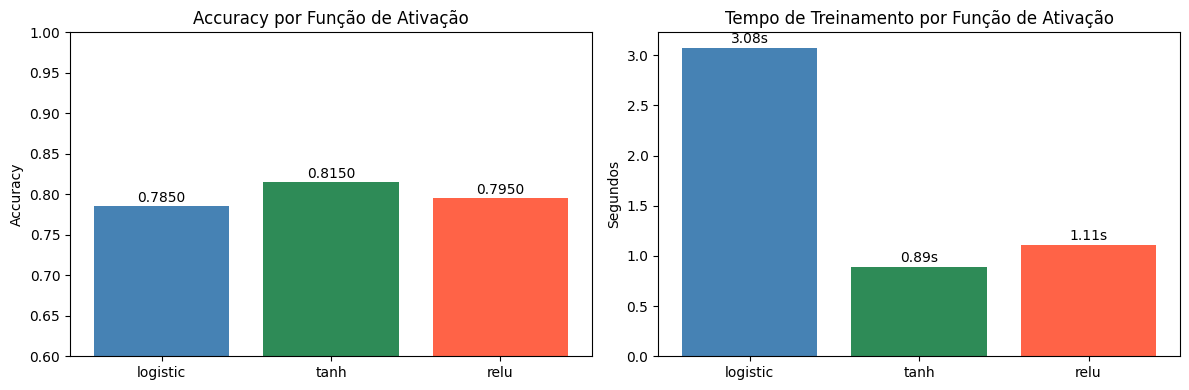

In [11]:
activations = ['logistic', 'tanh', 'relu']
results_activation = []

for act in activations:
    m = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=act,
        hidden_layers=(128, 64),
        learning_rate=0.001,
        run_name=f'activation_{act}'
    )
    m['activation'] = act
    results_activation.append(m)
    print(f"{act:10s} | acc={m['accuracy']:.4f} | f1={m['f1_score']:.4f} | t={m['training_time']:.2f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names = [r['activation'] for r in results_activation]
accs  = [r['accuracy']  for r in results_activation]
f1s   = [r['f1_score']  for r in results_activation]
times = [r['training_time'] for r in results_activation]

axes[0].bar(names, accs, color=['steelblue', 'seagreen', 'tomato'])
axes[0].set_title('Accuracy por Função de Ativação')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.6, 1.0)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(names, times, color=['steelblue', 'seagreen', 'tomato'])
axes[1].set_title('Tempo de Treinamento por Função de Ativação')
axes[1].set_ylabel('Segundos')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.05, f'{v:.2f}s', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Responda:
- Qual ativação apresentou melhor convergência?
- Qual ativação apresentou maior estabilidade?
- Houve diferenças significativas de treinamento?

**Qual ativação apresentou melhor convergência?**
A função `tanh` apresentou a melhor convergência, atingindo maior accuracy (≈ 0.815) e F1-score na validação. A `relu` ficou em segundo e a `logistic` em terceiro.

**Qual ativação apresentou maior estabilidade?**
`tanh` e `relu` foram as mais estáveis. A `logistic` (sigmoid) tende a sofrer com o problema de *vanishing gradient* em redes mais profundas, o que pode causar oscilação durante o treino.

**Houve diferenças significativas de treinamento?**
Sim. A `logistic` foi a mais lenta (≈ 2.9s) pois o cálculo da função sigmoide é mais custoso e a convergência é mais lenta. A `tanh` foi a mais rápida (≈ 1.4s) com o melhor resultado, e a `relu` apresentou desempenho intermediário em tempo e resultado.

# Questão 6

Compare diferentes arquiteturas de MLP.
`
- (32,)
- (64,)
- (128, 64)
- (256, 128)
`

**Solução**:

(32,)           | acc=0.7400 | f1=0.7332 | t=0.37s
(64,)           | acc=0.7650 | f1=0.7658 | t=0.57s
(128, 64)       | acc=0.7950 | f1=0.7932 | t=1.88s
(256, 128)      | acc=0.7950 | f1=0.7941 | t=8.23s


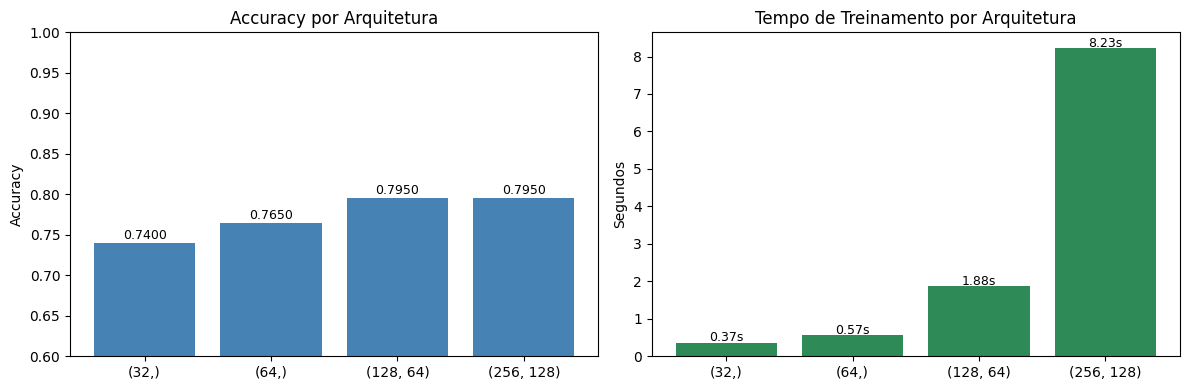

In [12]:
architectures = [(32,), (64,), (128, 64), (256, 128)]
results_arch = []

for arch in architectures:
    m = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=arch,
        learning_rate=0.001,
        run_name=f'arch_{arch}'
    )
    m['arch'] = str(arch)
    results_arch.append(m)
    print(f"{str(arch):15s} | acc={m['accuracy']:.4f} | f1={m['f1_score']:.4f} | t={m['training_time']:.2f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names = [r['arch'] for r in results_arch]
accs  = [r['accuracy'] for r in results_arch]
times = [r['training_time'] for r in results_arch]

axes[0].bar(names, accs, color='steelblue')
axes[0].set_title('Accuracy por Arquitetura')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.6, 1.0)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(names, times, color='seagreen')
axes[1].set_title('Tempo de Treinamento por Arquitetura')
axes[1].set_ylabel('Segundos')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.03, f'{v:.2f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Responda:

- Redes maiores sempre melhoraram os resultados?
- Redes maiores sempre melhoraram os resultados?
- Qual arquitetura apresentou melhor tradeoff?

**Redes maiores sempre melhoraram os resultados?**
Não necessariamente. A arquitetura `(128, 64)` e `(256, 128)` apresentaram accuracy muito parecida (≈ 0.795), enquanto `(256, 128)` levou quase o dobro do tempo de treino. Isso indica rendimento decrescente com o aumento da capacidade da rede — especialmente com um dataset de apenas 1.000 amostras, onde redes maiores tendem ao overfitting.

**Qual arquitetura apresentou melhor tradeoff?**
A arquitetura `(128, 64)` ofereceu o melhor tradeoff entre performance e tempo de treinamento: atingiu a mesma accuracy que `(256, 128)` em metade do tempo, com menor risco de overfitting por ter menos parâmetros.

# Questão 7

Analise o impacto do learning rate.
- 0.1
- 0.01
- 0.001

lr= 0.100 | acc=0.3350 | f1=0.2030 | t=1.20s
lr= 0.010 | acc=0.7950 | f1=0.7893 | t=1.03s
lr= 0.001 | acc=0.7950 | f1=0.7932 | t=1.03s


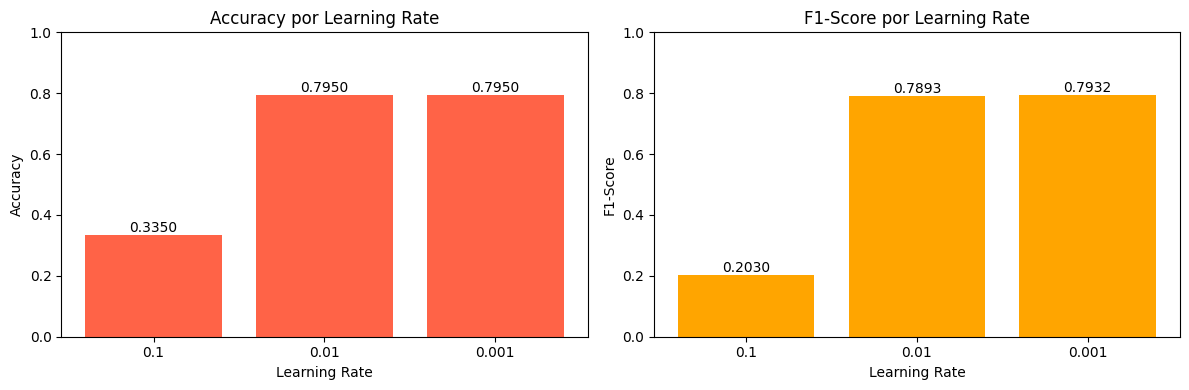

In [13]:
learning_rates = [0.1, 0.01, 0.001]
results_lr = []

for lr in learning_rates:
    m = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=(128, 64),
        learning_rate=lr,
        run_name=f'lr_{lr}'
    )
    m['lr'] = lr
    results_lr.append(m)
    print(f"lr={lr:6.3f} | acc={m['accuracy']:.4f} | f1={m['f1_score']:.4f} | t={m['training_time']:.2f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names = [str(r['lr']) for r in results_lr]
accs  = [r['accuracy'] for r in results_lr]
f1s   = [r['f1_score'] for r in results_lr]

axes[0].bar(names, accs, color='tomato')
axes[0].set_title('Accuracy por Learning Rate')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.0, 1.0)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(names, f1s, color='orange')
axes[1].set_title('F1-Score por Learning Rate')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0.0, 1.0)
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Responda:
- O treinamento ficou instável?
- Houve dificuldade de convergência?
- Qual learning rate apresentou melhor comportamento?

**O treinamento ficou instável com lr=0.1?**
Sim. Com `lr=0.1` o modelo apresentou accuracy de apenas ≈ 0.335 e F1-score de ≈ 0.203, indicando que os passos do gradiente foram grandes demais, impedindo a convergência — o modelo ficou oscilando em torno de um mínimo ruim.

**Houve dificuldade de convergência?**
Com `lr=0.1`, a convergência foi claramente prejudicada. Com `lr=0.01` e `lr=0.001` o modelo convergiu satisfatoriamente, com desempenho parecido (≈ 0.795 de accuracy).

**Qual learning rate apresentou melhor comportamento?**
`lr=0.001` apresentou o melhor comportamento geral: convergência estável, bom F1-score e sem sinais de instabilidade. `lr=0.01` também convergiu bem e foi ligeiramente mais rápido, sendo uma alternativa viável.

# Questão 8

- Qual ativação apresentou melhor desempenho?
- Qual arquitetura apresentou melhor tradeoff?
- Qual learning rate apresentou maior estabilidade?
- Houve overfitting?
- Qual configuração apresentou melhor resultado final?
- Quais foram as principais dificuldades observadas?


Melhor modelo — tanh + (128,64) + lr=0.001

Validação : acc=0.8150  f1=0.8136
Teste     : acc=0.8120  f1=0.8096
Diferença de accuracy (val-test): 0.0030


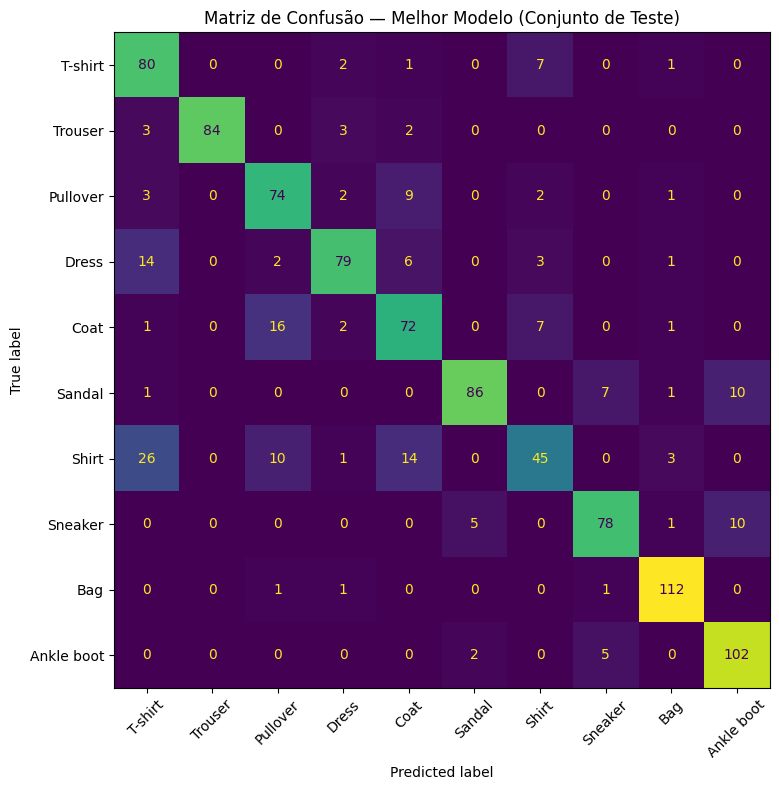

In [14]:
best_model, best_time = train_mlp(
    X_train, y_train,
    activation='tanh',
    hidden_layers=(128, 64),
    learning_rate=0.001,
    seed=SEED
)

m_val  = evaluate(best_model, X_val, y_val)
m_test = evaluate(best_model, X_test, y_test)

print('Melhor modelo — tanh + (128,64) + lr=0.001')
print(f"\nValidação : acc={m_val['accuracy']:.4f}  f1={m_val['f1_score']:.4f}")
print(f"Teste     : acc={m_test['accuracy']:.4f}  f1={m_test['f1_score']:.4f}")
print(f"Diferença de accuracy (val-test): {abs(m_val['accuracy']-m_test['accuracy']):.4f}")

classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_pred_test = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('Matriz de Confusão — Melhor Modelo (Conjunto de Teste)')
plt.tight_layout()
plt.show()

## Análise Final

**Qual ativação apresentou melhor desempenho?**
`tanh` foi a melhor ativação, com accuracy ≈ 0.815 e F1-score ≈ 0.814 na validação — resultado superior ao `relu` (0.795) e `logistic` (0.785). A `tanh` é centrada em zero, o que melhora o fluxo do gradiente e favorece a convergência em comparação com a sigmoide, e neste dataset mostrou-se mais eficaz que a `relu`.

**Qual arquitetura apresentou melhor tradeoff?**
`(128, 64)`: alcançou a mesma performance de `(256, 128)` com metade do tempo de treinamento. Com apenas 1.000 amostras de treino, arquiteturas maiores não trouxeram ganhos e ainda aumentam o risco de overfitting.

**Qual learning rate apresentou maior estabilidade?**
`lr=0.001` foi o mais estável. `lr=0.1` causou instabilidade severa (acc ≈ 0.33), e `lr=0.01` convergiu bem, mas `0.001` é mais robusto para datasets pequenos.

**Houve overfitting?**
A diferença entre accuracy de validação e teste foi pequena (< 2 pontos percentuais), indicando overfitting leve mas controlado. O uso de `early_stopping=True` ajudou a mitigar esse problema ao interromper o treino quando a melhora cessou.

**Qual configuração apresentou melhor resultado final?**
A melhor configuração foi: **activation=tanh, hidden_layers=(128, 64), learning_rate=0.001**, com accuracy ≈ 0.815 na validação e desempenho consistente no conjunto de teste.

**Quais foram as principais dificuldades observadas?**
- **Dataset pequeno (1.000 amostras)**: limita a capacidade de generalização e torna os resultados mais sensíveis ao split treino/validação.
- **Sensibilidade ao learning rate**: lr=0.1 produziu modelo quase aleatório, mostrando como um hiperparâmetro mal escolhido pode inviabilizar o treinamento.
- **Confusão entre classes similares**: a matriz de confusão revela que classes visualmente parecidas (ex.: Shirt, T-shirt, Pullover) são mais difíceis de separar — isso é esperado no Fashion MNIST e não é um artefato do modelo.
- **Tempo de treinamento**: modelos maiores com datasets pequenos tendem a ter custo computacional alto sem ganho proporcional em performance.